In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

TUKWILA_CSV = 'tukwila.csv'
IPDR_CSV    = 'ipdatarecord-txrx-nonzero-raemis.csv'
OUTPUT_DIR  = 'figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def out(fname):
    return os.path.join(OUTPUT_DIR, fname)

Demographic Comparison

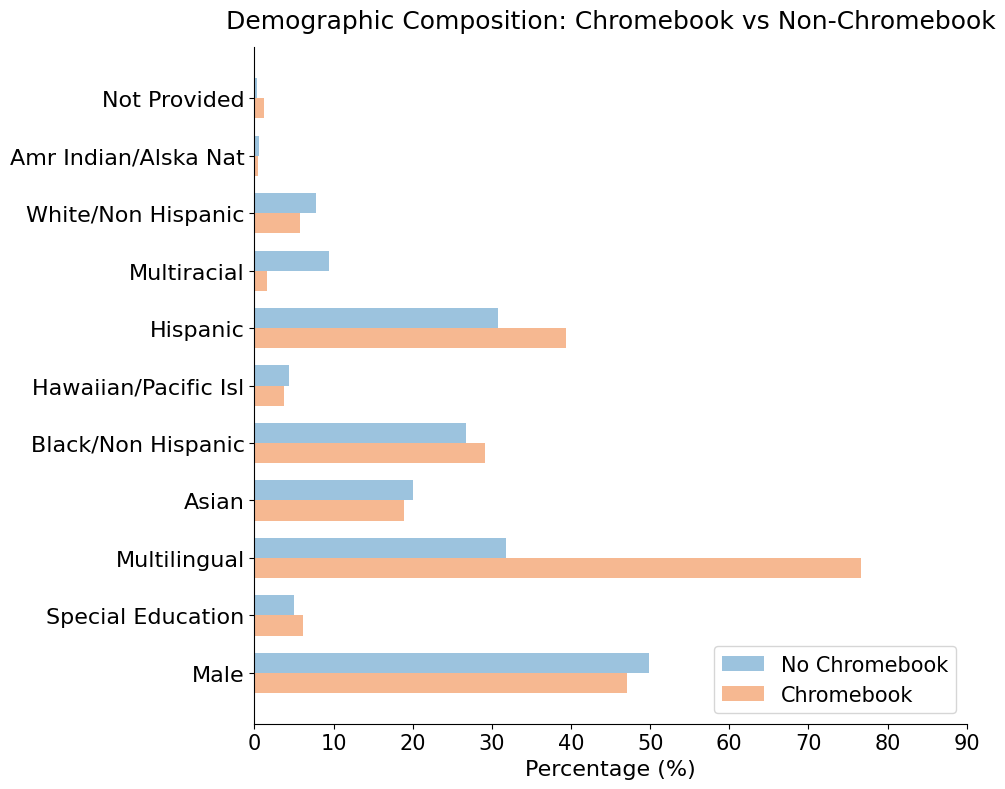

In [2]:
df = pd.read_csv(TUKWILA_CSV)
df['Chromebook'] = ((df['2023-2024 Chromebook'] == 'Y') |
                    (df['2024-2025 Chromebook'] == 'Y'))
cb = df[df['Chromebook'] == True]
no_cb = df[df['Chromebook'] == False]

rows = [
    ('Male',                 'Sex',                   'M'),
    ('Special Education',    'Special Education',      'Y'),
    ('Multilingual',         '2024-2025 Multilingual', 'Y'),
    ('Asian',                'LocalRace',              'ASIAN'),
    ('Black/Non Hispanic',   'LocalRace',              'BLACK/NON HISPANIC'),
    ('Hawaiian/Pacific Isl', 'LocalRace',              'HAWAIIAN/PACIFIC ISL'),
    ('Hispanic',             'LocalRace',              'HISPANIC'),
    ('Multiracial',          'LocalRace',              'MULTIRACIAL'),
    ('White/Non Hispanic',   'LocalRace',              'WHITE/NON HISPANIC'),
    ('Amr Indian/Alska Nat', 'LocalRace',              'AMR INDIAN/ALSKA NAT'),
    ('Not Provided',         'LocalRace',              'NOT PROVIDED'),
]

labels, cb_pcts, no_cb_pcts = [], [], []
for label, col, val in rows:
    labels.append(label)
    cb_pcts.append(100 * (cb[col] == val).sum() / len(cb))
    no_cb_pcts.append(100 * (no_cb[col] == val).sum() / len(no_cb))

y, h = np.arange(len(labels)), 0.35
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(y + h/2, no_cb_pcts, h, label='No Chromebook', color='#7BAFD4', alpha=0.75)
ax.barh(y - h/2, cb_pcts,    h, label='Chromebook',    color='#F4A06D', alpha=0.75)
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=16)
ax.set_xlabel('Percentage (%)', fontsize=16)
ax.set_title('Demographic Composition: Chromebook vs Non-Chromebook', fontsize=18, pad=14)
ax.tick_params(axis='x', labelsize=15)
ax.legend(fontsize=15, frameon=True, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, 90)
plt.tight_layout()
plt.savefig(out('demographic_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 2. GPA Distribution (including GPA = 0)

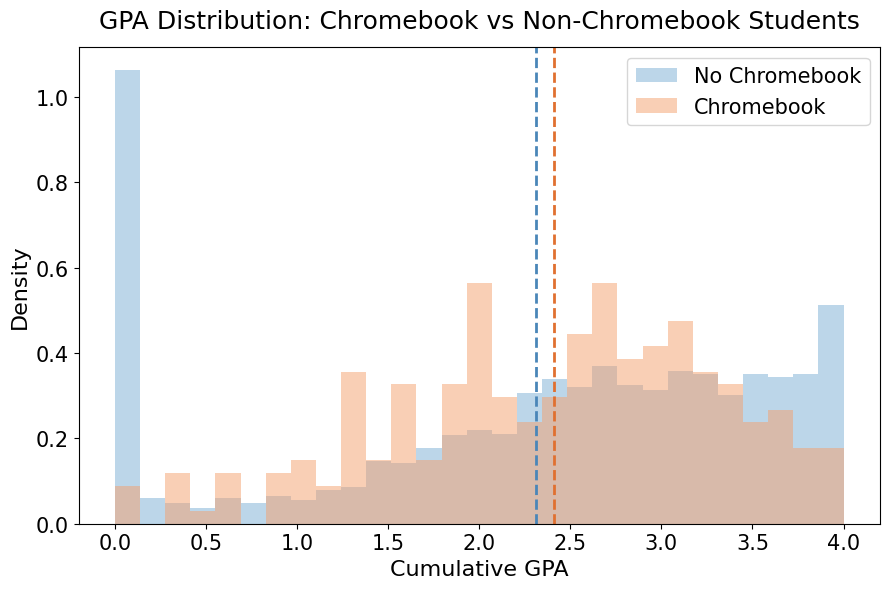

In [3]:
df = pd.read_csv(TUKWILA_CSV)
df['Chromebook'] = ((df['2023-2024 Chromebook'] == 'Y') |
                    (df['2024-2025 Chromebook'] == 'Y'))
cb_gpa    = df[df['Chromebook'] == True]['Cumulative GPA'].dropna()
no_cb_gpa = df[df['Chromebook'] == False]['Cumulative GPA'].dropna()

bins = np.linspace(0, 4, 30)
fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(no_cb_gpa, bins=bins, density=True, alpha=0.5, color='#7BAFD4', label='No Chromebook')
ax.hist(cb_gpa,    bins=bins, density=True, alpha=0.5, color='#F4A06D', label='Chromebook')
ax.axvline(no_cb_gpa.mean(), color='#4A86B8', linestyle='--', linewidth=2)
ax.axvline(cb_gpa.mean(),    color='#E07030', linestyle='--', linewidth=2)
ax.set_xlabel('Cumulative GPA', fontsize=16)
ax.set_ylabel('Density', fontsize=16)
ax.set_title('GPA Distribution: Chromebook vs Non-Chromebook Students', fontsize=18, pad=14)
ax.tick_params(axis='both', labelsize=15)
ax.legend(fontsize=15, frameon=True)
plt.tight_layout()
plt.savefig(out('gpa_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Network Usage Distribution

n=97, median=7.83 MB, mean=1708.71 MB, max=54595.70 MB


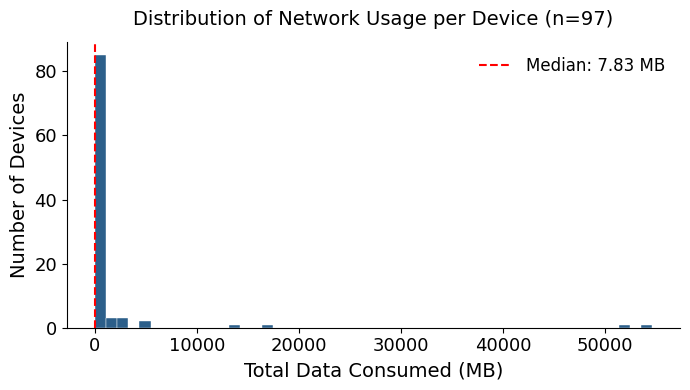

In [4]:
df = pd.read_csv(IPDR_CSV)
df['tx_and_rx_mb'] = (df['tx_total_packets'] + df['rx_total_packets']) * 1500 / 1000000
user_mb = df.groupby('sub_ref_1')['tx_and_rx_mb'].sum()

print(f"n={len(user_mb)}, median={user_mb.median():.2f} MB, mean={user_mb.mean():.2f} MB, max={user_mb.max():.2f} MB")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(user_mb, bins=50, color='#2C5F8A', edgecolor='white', linewidth=0.3)
ax.axvline(user_mb.median(), color='red', linestyle='--', linewidth=1.5,
           label=f'Median: {user_mb.median():.2f} MB')
ax.set_xlabel('Total Data Consumed (MB)', fontsize=14)
ax.set_ylabel('Number of Devices', fontsize=14)
ax.set_title('Distribution of Network Usage per Device (n=97)', fontsize=14, pad=12)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=12, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(out('network_usage_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

Hourly Network Usage Charts

school_weekday: 250 days


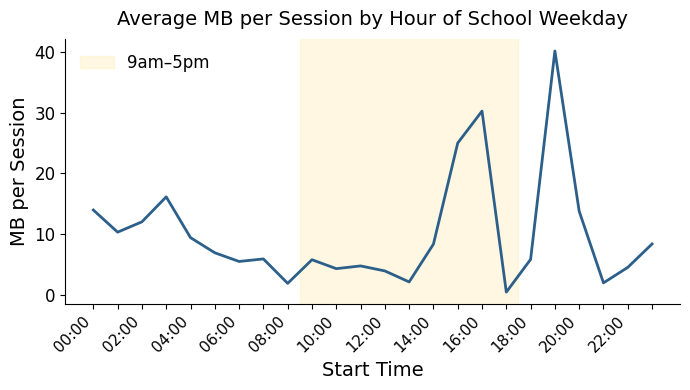

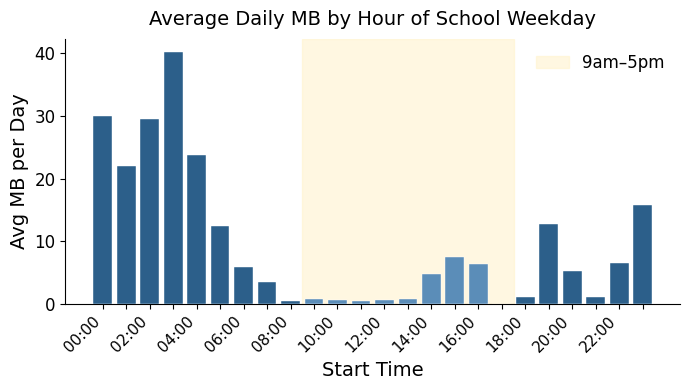

school_weekend: 98 days


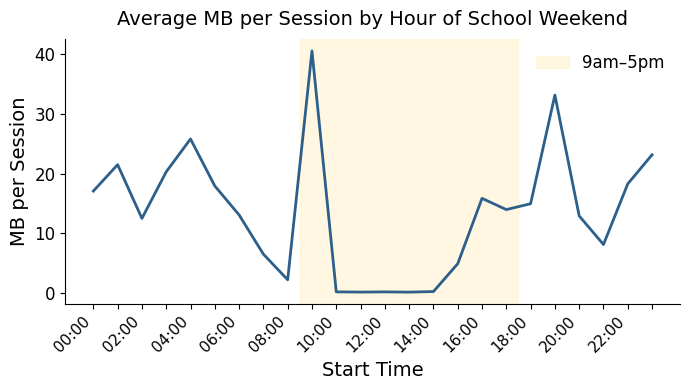

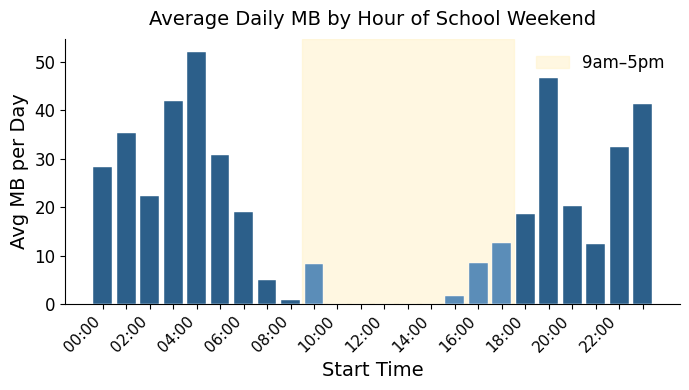

summer_weekday: 85 days


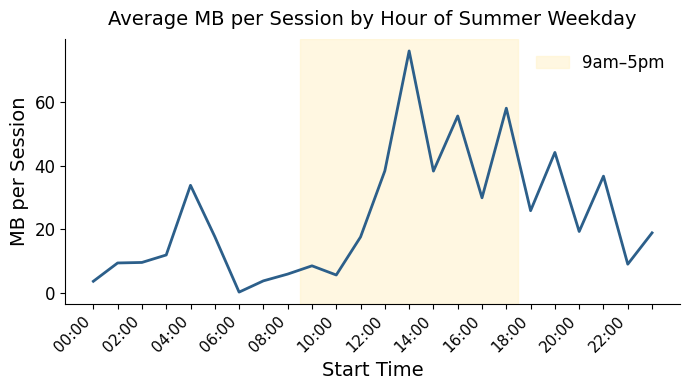

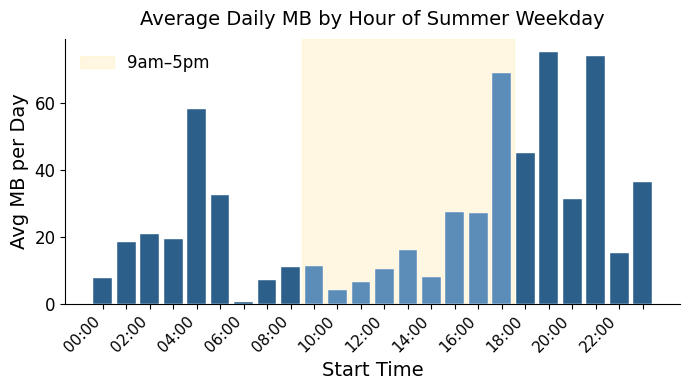

summer_weekend: 34 days


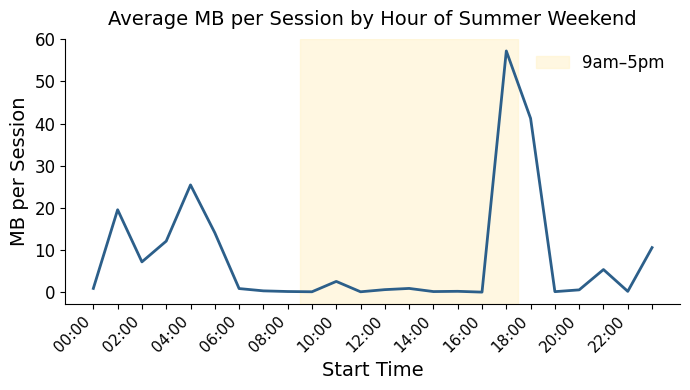

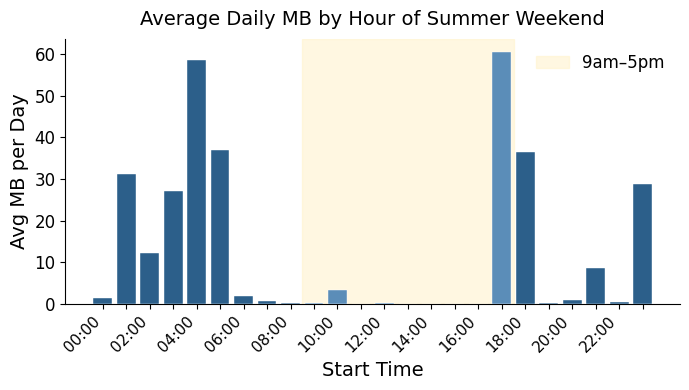

In [5]:
df = pd.read_csv(IPDR_CSV)
df['start_time'] = pd.to_datetime(df['start_time'])
df['tx_and_rx_mb'] = (df['tx_total_packets'] + df['rx_total_packets']) * 1500 / 1000000

school = df.loc[((df['start_time'] >= '2024-09-03') & (df['start_time'] < '2025-06-18'))
                | (df['start_time'] >= '2025-09-03')]
summer = df.loc[(df['start_time'] < '2024-09-03') |
                ((df['start_time'] >= '2025-06-18') & (df['start_time'] < '2025-09-03'))]

partitions = {
    'school_weekday': (school[school['start_time'].dt.dayofweek < 5].copy(),  'School Weekday'),
    'school_weekend': (school[school['start_time'].dt.dayofweek >= 5].copy(), 'School Weekend'),
    'summer_weekday': (summer[summer['start_time'].dt.dayofweek < 5].copy(),  'Summer Weekday'),
    'summer_weekend': (summer[summer['start_time'].dt.dayofweek >= 5].copy(), 'Summer Weekend'),
}

xlabels = [f'{h:02d}:00' if h % 2 == 0 else '' for h in range(24)]

for key, (d, title) in partitions.items():
    d['hour'] = d['start_time'].dt.hour
    n_days = d['start_time'].dt.date.nunique()
    hourly = d.groupby('hour')['tx_and_rx_mb'].agg(['mean', 'sum']).reindex(range(24), fill_value=0).reset_index()
    hourly['avg_per_day'] = hourly['sum'] / n_days
    print(f"{key}: {n_days} days")

    # Avg per session
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.axvspan(8.5, 17.5, color='#FFF3CD', alpha=0.6, zorder=0, label='9am–5pm')
    ax.plot(hourly['hour'], hourly['mean'], color='#2C5F8A', linewidth=2, zorder=3)
    ax.set_xlabel('Start Time', fontsize=14)
    ax.set_ylabel('MB per Session', fontsize=14)
    ax.set_title(f'Average MB per Session by Hour of {title}', fontsize=14, pad=10)
    ax.set_xticks(range(24))
    ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=11)
    ax.tick_params(axis='y', labelsize=12)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=12, frameon=False)
    plt.tight_layout()
    plt.savefig(out(f'{key}_avg.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # Avg per day
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.axvspan(8.5, 17.5, color='#FFF3CD', alpha=0.6, zorder=0, label='9am–5pm')
    colors = ['#5B8DB8' if (9 <= h <= 17) else '#2C5F8A' for h in hourly['hour']]
    ax.bar(hourly['hour'], hourly['avg_per_day'], color=colors,
           edgecolor='white', linewidth=0.3, zorder=3)
    ax.set_xlabel('Start Time', fontsize=14)
    ax.set_ylabel('Avg MB per Day', fontsize=14)
    ax.set_title(f'Average Daily MB by Hour of {title}', fontsize=14, pad=10)
    ax.set_xticks(range(24))
    ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=11)
    ax.tick_params(axis='y', labelsize=12)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=12, frameon=False)
    plt.tight_layout()
    plt.savefig(out(f'{key}_sum.png'), dpi=150, bbox_inches='tight')
    plt.show()